# 1 线性回归之正规方程

特征中的缺失值:
0
目标变量中的缺失值: 0

数据集完整，没有缺失值或无穷大值。
特征名称: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
数据集形状: (20640, 8)
目标变量形状: (20640,)
[1.03    3.821   1.726   0.934   0.965   2.648   1.573   5.00001 1.398
 3.156  ]
均方误差 (MSE): 0.5559

模型回归系数:
MedInc: 0.4487
HouseAge: 0.0097
AveRooms: -0.1233
AveBedrms: 0.7831
Population: -0.0000
AveOccup: -0.0035
Latitude: -0.4198
Longitude: -0.4337
截距: -37.0233


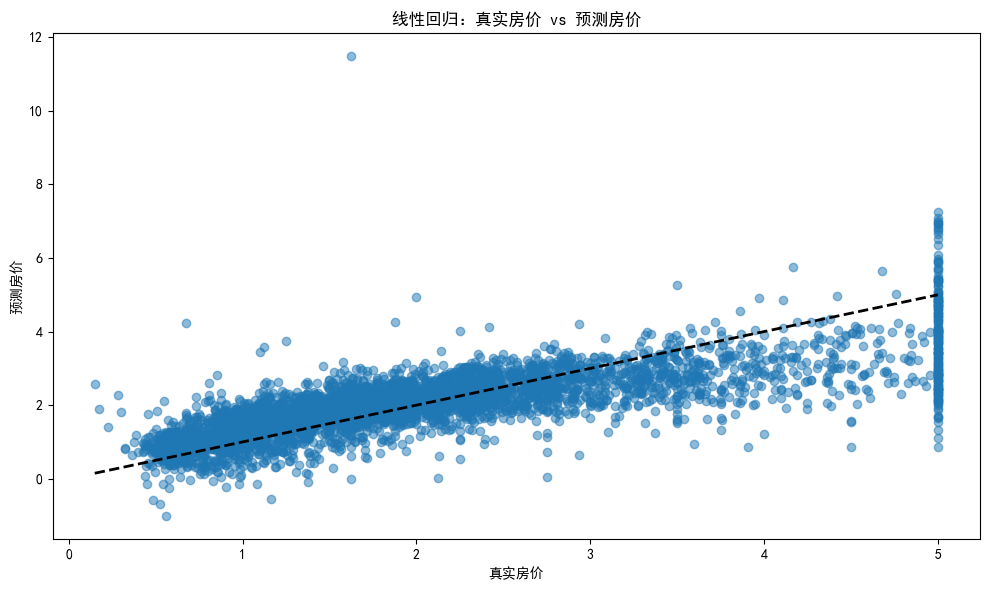

In [4]:
# 线性回归（正规方程/SVD）：加利福尼亚房价预测基线模型

import numpy as np  # 数值计算库
import pandas as pd  # 数据处理库
import matplotlib.pyplot as plt  # 绘图库
from sklearn.datasets import fetch_california_housing  # 加载加利福尼亚房价数据集
from sklearn.model_selection import train_test_split  # 训练/测试集划分
from sklearn.linear_model import LinearRegression  # 普通最小二乘线性回归；内部用正规方程或 SVD
from sklearn.metrics import mean_squared_error, r2_score  # MSE：均方误差；R²：决定系数

housing = fetch_california_housing(data_home='./data')  # 加载数据；data形状(20640,8)，target为房价中位数
X = housing.data  # 特征矩阵；ndarray，形状 (20640, 8)
y = housing.target  # 目标值（房价中位数，单位10万美元）；ndarray，形状 (20640,)

missing_values = np.isnan(X).sum()  # isnan 返回布尔矩阵，sum 统计每列 True 的个数；返回 ndarray
print("特征中的缺失值:")  # 打印标题
print(missing_values)  # 打印各列缺失数；应全为 0

missing_target = np.isnan(y).sum()  # 统计目标列缺失数；返回 int
print(f"目标变量中的缺失值: {missing_target}")  # 打印缺失数

if missing_values.sum() == 0 and missing_target == 0:  # 判断特征和目标均无缺失
    print("\n数据集完整，没有缺失值或无穷大值。")  # 打印完整性确认
else:  # 存在缺失则提示需要清洗
    print("\n数据集存在缺失值或无穷大值，需要进行数据清洗。")  # 打印清洗提示

print("特征名称:", housing.feature_names)  # list[str]，8 个特征名
print("数据集形状:", X.shape)  # 应输出 (20640, 8)
print("目标变量形状:", y.shape)  # 应输出 (20640,)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 80%训练，20%测试
print(y_train[:10])  # 打印前 10 个训练标签，确认数据值域

lr_model = LinearRegression()  # 初始化线性回归；coef_形状(8,)，intercept_为标量

lr_model.fit(X_train, y_train)  # 估计最小二乘解；返回已拟合的模型自身

y_pred = lr_model.predict(X_test)  # 对测试集预测；返回 ndarray，长度=len(y_test)

mse = mean_squared_error(y_test, y_pred)  # 均方误差=(预测值-真实值)²的均值；越小越好
print(f"均方误差 (MSE): {mse:.4f}")  # 打印 MSE

print("\n模型回归系数:")  # 打印标题
for name, coef in zip(housing.feature_names, lr_model.coef_):  # zip 将特征名与系数配对；coef_类型 ndarray
    print(f"{name}: {coef:.4f}")  # 该特征每增加 1 单位，房价变化 coef 单位
print(f"截距: {lr_model.intercept_:.4f}")  # 所有特征为 0 时的预测基线；标量 float

plt.figure(figsize=(10, 6))  # 创建图窗
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False  # 禁用 unicode 负号
plt.scatter(y_test, y_pred, alpha=0.5)  # 散点图；横轴=真实房价，纵轴=预测房价
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # 绘制 y=x 理想参考线
plt.xlabel('真实房价')  # x 轴标签
plt.ylabel('预测房价')  # y 轴标签
plt.title('线性回归：真实房价 vs 预测房价')  # 图标题
plt.tight_layout()  # 自动调整布局
plt.show()  # 渲染图像


特征中的缺失值:
0
目标变量中的缺失值: 0

数据集完整，没有缺失值或无穷大值。
特征名称: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
数据集形状: (20640, 8)
目标变量形状: (20640,)
[1.03    3.821   1.726   0.934   0.965   2.648   1.573   5.00001 1.398
 3.156  ]
均方误差 (MSE): 0.5559

模型回归系数:
MedInc: 0.8544
HouseAge: 0.1225
AveRooms: -0.2944
AveBedrms: 0.3393
Population: -0.0023
AveOccup: -0.0408
Latitude: -0.8969
Longitude: -0.8698
截距: 2.0719

模型和标准化器已保存


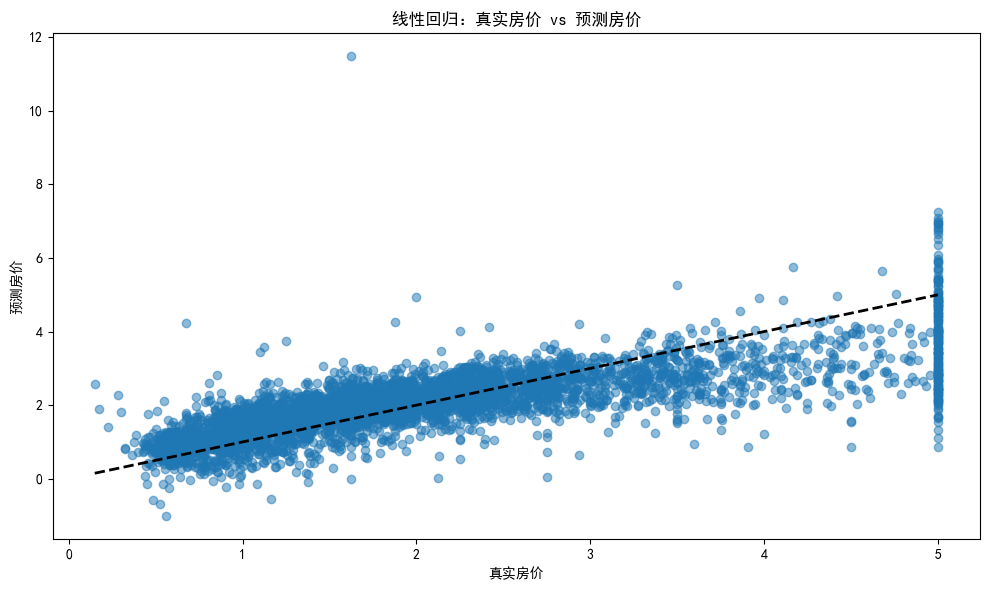

In [5]:
# 标准化 + 线性回归 + 模型序列化（joblib 保存/加载）

import numpy as np  # 数值计算
import pandas as pd  # 数据处理
import matplotlib.pyplot as plt  # 绘图
from sklearn.datasets import fetch_california_housing  # 加载加利福尼亚房价数据集
from sklearn.model_selection import train_test_split  # 数据集划分
from sklearn.linear_model import LinearRegression  # 线性回归模型
from sklearn.metrics import mean_squared_error, r2_score  # 评估指标
from sklearn.preprocessing import StandardScaler  # 特征标准化：零均值、单位方差
import joblib  # sklearn 推荐的模型序列化工具；比 pickle 更高效处理大型 ndarray

housing = fetch_california_housing(data_home='./data')  # 加载数据
X = housing.data  # 特征矩阵；ndarray，(20640, 8)
y = housing.target  # 目标值；ndarray，(20640,)

missing_values = np.isnan(X).sum()  # 检查特征缺失；返回 ndarray
print("特征中的缺失值:")  # 打印标题
print(missing_values)  # 各列缺失数

missing_target = np.isnan(y).sum()  # 检查目标缺失；返回 int
print(f"目标变量中的缺失值: {missing_target}")  # 打印

if missing_values.sum() == 0 and missing_target == 0:  # 双条件判断
    print("\n数据集完整，没有缺失值或无穷大值。")  # 完整提示
else:  # 否则
    print("\n数据集存在缺失值或无穷大值，需要进行数据清洗。")  # 清洗提示

print("特征名称:", housing.feature_names)  # 8 个特征名
print("数据集形状:", X.shape)  # (20640, 8)
print("目标变量形状:", y.shape)  # (20640,)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 划分数据集
print(y_train[:10])  # 打印前 10 个训练标签

scaler = StandardScaler()  # 初始化标准化器
X_train_scaled = scaler.fit_transform(X_train)  # 在训练集上估计均值/方差并变换；返回 ndarray
X_test_scaled = scaler.transform(X_test)  # 用训练集统计量变换测试集；防止数据泄漏

lr_model = LinearRegression()  # 初始化线性回归模型
lr_model.fit(X_train_scaled, y_train)  # 在标准化后的训练集上拟合

y_pred = lr_model.predict(X_test_scaled)  # 预测测试集；返回 ndarray

mse = mean_squared_error(y_test, y_pred)  # 均方误差；float
print(f"均方误差 (MSE): {mse:.4f}")  # 打印 MSE

print("\n模型回归系数:")  # 打印标题
for name, coef in zip(housing.feature_names, lr_model.coef_):  # 遍历特征名与系数对
    print(f"{name}: {coef:.4f}")  # 打印每个特征的系数
print(f"截距: {lr_model.intercept_:.4f}")  # 打印截距

joblib.dump(lr_model, 'linear_regression_model.pkl')  # 将模型序列化保存到当前目录；文件名任意
joblib.dump(scaler, 'scaler.pkl')  # 同时保存 scaler；预测新样本时必须用同一 scaler 变换
print("\n模型和标准化器已保存")  # 打印保存确认

plt.figure(figsize=(10, 6))  # 创建图窗
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False  # 禁用 unicode 负号
plt.scatter(y_test, y_pred, alpha=0.5)  # 散点图；横轴真实值，纵轴预测值
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # 绘制 y=x 参考线
plt.xlabel('真实房价')  # x 轴标签
plt.ylabel('预测房价')  # y 轴标签
plt.title('线性回归：真实房价 vs 预测房价')  # 图标题
plt.tight_layout()  # 自动调整布局
plt.show()  # 渲染图像


## 加载模型并预测

In [3]:
# 加载已保存模型和 Scaler，对新样本与整个测试集进行预测

import joblib  # 模型反序列化工具
from sklearn.datasets import fetch_california_housing  # 重新加载数据（与保存时保持相同划分）
from sklearn.model_selection import train_test_split  # 数据集划分

loaded_scaler = joblib.load('scaler.pkl')  # 加载已保存的 StandardScaler 对象
loaded_model = joblib.load('linear_regression_model.pkl')  # 加载已保存的 LinearRegression 对象
print("模型和标准化器已加载")  # 打印加载确认

housing = fetch_california_housing(data_home='./data')  # 加载数据集
X = housing.data  # 特征矩阵；ndarray，(20640, 8)
y = housing.target  # 目标值；ndarray，(20640,)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 必须用相同 random_state 保证划分一致
new_house_data = X_test[[-1], :]  # 取测试集最后一行作为新样本；[[-1]] 保持二维形状 (1, 8)

new_house_data_scaled = loaded_scaler.transform(new_house_data)  # 用训练时的 scaler 标准化新样本；不能重新 fit

predicted_price = loaded_model.predict(new_house_data_scaled)  # 预测单个样本；返回长度为 1 的 ndarray
print(f"预测的房价: {predicted_price[0]:.2f}")  # 取第 0 个元素；单位为 10 万美元
print('-'*100)  # 打印分隔线

X_test_scaled = loaded_scaler.transform(X_test)  # 标准化整个测试集
y_pred = loaded_model.predict(X_test_scaled)  # 预测整个测试集；返回 ndarray

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # 导入多个评估指标

mse = mean_squared_error(y_test, y_pred)  # 均方误差；float
print("\n模型评估指标:")  # 打印标题
print(f"均方误差 (MSE): {mse:.4f}")  # 打印 MSE


模型和标准化器已加载
预测的房价: 2.01
----------------------------------------------------------------------------------------------------

模型评估指标:
均方误差 (MSE): 0.5559


# 线性回归之梯度下降

### 形象理解梯度下降

第1次迭代，x=1.4000,f(x)=10.6800
第2次迭代，x=0.3600,f(x)=3.1088
第3次迭代，x=-0.0560,f(x)=1.8974
第4次迭代，x=-0.2224,f(x)=1.7036
第5次迭代，x=-0.2890,f(x)=1.6726
第6次迭代，x=-0.3156,f(x)=1.6676
第7次迭代，x=-0.3262,f(x)=1.6668
第8次迭代，x=-0.3305,f(x)=1.6667
第9次迭代，x=-0.3322,f(x)=1.6667
第10次迭代，x=-0.3329,f(x)=1.6667
第11次迭代，x=-0.3332,f(x)=1.6667
第12次迭代，x=-0.3333,f(x)=1.6667
第13次迭代，x=-0.3333,f(x)=1.6667
第14次迭代，x=-0.3333,f(x)=1.6667
第15次迭代，x=-0.3333,f(x)=1.6667
第16次迭代，x=-0.3333,f(x)=1.6667
第17次迭代，x=-0.3333,f(x)=1.6667
第18次迭代，x=-0.3333,f(x)=1.6667
第19次迭代，x=-0.3333,f(x)=1.6667
第20次迭代，x=-0.3333,f(x)=1.6667


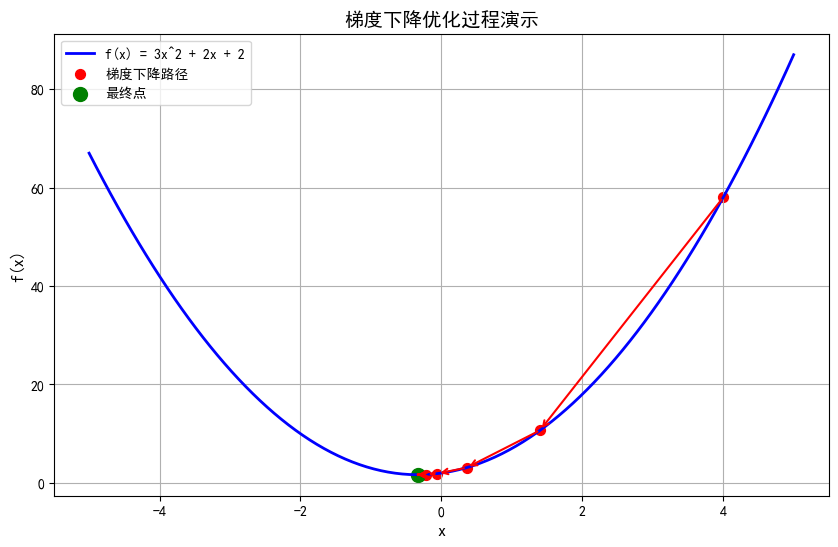

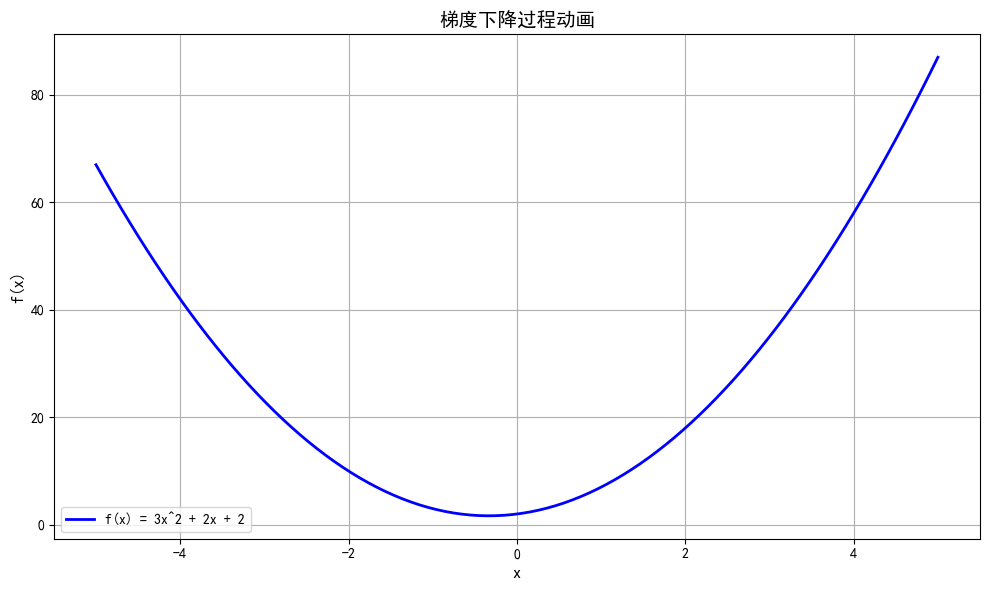

In [12]:
# 梯度下降直觉演示：在一元二次函数上手动迭代并用动画展示收敛过程

import numpy as np  # 数值计算
import matplotlib.pyplot as plt  # 绘图
from matplotlib.animation import FuncAnimation  # 动画工具；逐帧更新图形

def f(x):  # 目标函数定义
    """目标函数 f(x)=3x²+2x+2；输入 float/ndarray，返回同类型结果。"""
    return 3*x**2 + 2*x + 2  # 一元二次函数；最小值在 x=-1/3 处

def df(x):  # 导数（梯度）定义
    """f 的导数 f'(x)=6x+2；梯度下降沿负梯度方向更新。"""
    return 6*x + 2  # 对 f(x) 求导；用于指示下降方向

plt.figure(figsize=(10, 6))  # 创建第一幅图窗（静态路径图）

x = np.linspace(-5, 5, 100)  # 生成 [-5,5] 上均匀分布的 100 个点；类型 ndarray
y = f(x)  # 计算各点对应的函数值；返回同形状 ndarray

plt.plot(x, y, 'b-', linewidth=2, label='f(x) = 3x^2 + 2x + 2')  # 绘制蓝色实线函数曲线

learning_rate = 0.1  # 学习率 α；步长过大会在最小值附近震荡，过小收敛慢
max_iterations = 20  # 最大迭代次数；未提前收敛则执行到此为止
x_start = 4.0  # 初始点；选在远离最优解处以观察下降过程

x_history = [x_start]  # 记录每次迭代的 x 值；类型 list[float]
y_history = [f(x_start)]  # 记录对应的 f(x) 值；类型 list[float]

current_x = x_start  # 当前迭代点；初始化为起始点
for i in range(max_iterations):  # 循环最多 max_iterations 次；i 为迭代计数
    gradient = df(current_x)  # 计算当前点的梯度（导数值）；返回 float
    new_x = current_x - learning_rate * gradient  # 沿负梯度方向移动：x_new = x - α·f'(x)

    x_history.append(new_x)  # 记录新 x 值
    print(f'第{i+1}次迭代，x={new_x:.4f},f(x)={f(new_x):.4f}')  # 打印迭代进度
    y_history.append(f(new_x))  # 记录新 f(x) 值

    current_x = new_x  # 更新当前点

    if abs(gradient) < 1e-6:  # 梯度绝对值接近 0 则认为已收敛，提前退出
        break  # 跳出 for 循环

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False  # 禁用 unicode 负号
plt.scatter(x_history, y_history, c='r', s=50, label='梯度下降路径')  # 红色散点标注迭代位置
for i in range(len(x_history)-1):  # 遍历相邻迭代点，画箭头
    plt.annotate('', xy=(x_history[i+1], y_history[i+1]),  # 箭头终点（下一迭代点）
                 xytext=(x_history[i], y_history[i]),  # 箭头起点（当前迭代点）
                 arrowprops={'arrowstyle': '->', 'color': 'red', 'lw': 1.5})  # 红色箭头样式

plt.scatter(x_history[-1], y_history[-1], c='g', s=100, label='最终点')  # 绿色大点标注最终收敛点

plt.xlabel('x', fontsize=12)  # x 轴标签
plt.ylabel('f(x)', fontsize=12)  # y 轴标签
plt.title('梯度下降优化过程演示', fontsize=14)  # 图标题
plt.legend()  # 显示图例
plt.grid(True)  # 显示网格

fig, ax = plt.subplots(figsize=(10, 6))  # 创建第二幅图窗（动画用）

ax.plot(x, y, 'b-', linewidth=2, label='f(x) = 3x^2 + 2x + 2')  # 绘制函数曲线
ax.set_xlabel('x', fontsize=12)  # x 轴标签
ax.set_ylabel('f(x)', fontsize=12)  # y 轴标签
ax.set_title('梯度下降过程动画', fontsize=14)  # 图标题
ax.grid(True)  # 显示网格

point, = ax.plot([], [], 'ro', markersize=10)  # 动画中的移动点；返回 Line2D 对象
text = ax.text(0.05, 0.95, '', transform=ax.transAxes, verticalalignment='top')  # 图内文本框，显示迭代信息

def init():  # 动画初始化函数，在第一帧前调用
    """清空动点和文本，返回需要更新的 Artists。"""
    point.set_data([], [])  # 清空点的坐标
    text.set_text('')  # 清空文本
    return point, text  # 返回元组，blit=True 时只重绘这些元素

def update(frame):  # 动画更新函数，每帧调用一次
    """更新动点位置和信息文本；frame 为当前帧索引 int，从 0 开始。"""
    point.set_data(x_history[frame], y_history[frame])  # 将点移到第 frame 次迭代的位置
    text.set_text(f'迭代: {frame}\nx = {x_history[frame]:.4f}\nf(x) = {y_history[frame]:.4f}')  # 更新文本
    return point, text  # 返回更新后的 Artists

ani = FuncAnimation(fig, update, frames=len(x_history),  # frames：总帧数
                    init_func=init, blit=True, interval=500)  # interval=500ms 每帧间隔；blit=True 只重绘变化部分

plt.legend()  # 显示图例
plt.tight_layout()  # 自动调整布局
plt.show()  # 渲染动画


### 实战线性回归之梯度下降

特征中的缺失值:
0
目标变量中的缺失值: 0

数据集完整，没有缺失值或无穷大值。
特征名称: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
数据集形状: (20640, 8)
目标变量形状: (20640,)
[1.03    3.821   1.726   0.934   0.965   2.648   1.573   5.00001 1.398
 3.156  ]
均方误差 (MSE): 0.5506

模型回归系数:
MedInc: 0.8126
HouseAge: 0.1148
AveRooms: -0.2503
AveBedrms: 0.3024
Population: 0.0023
AveOccup: -0.1365
Latitude: -0.9093
Longitude: -0.8906
截距: 2.0573

模型和标准化器已保存


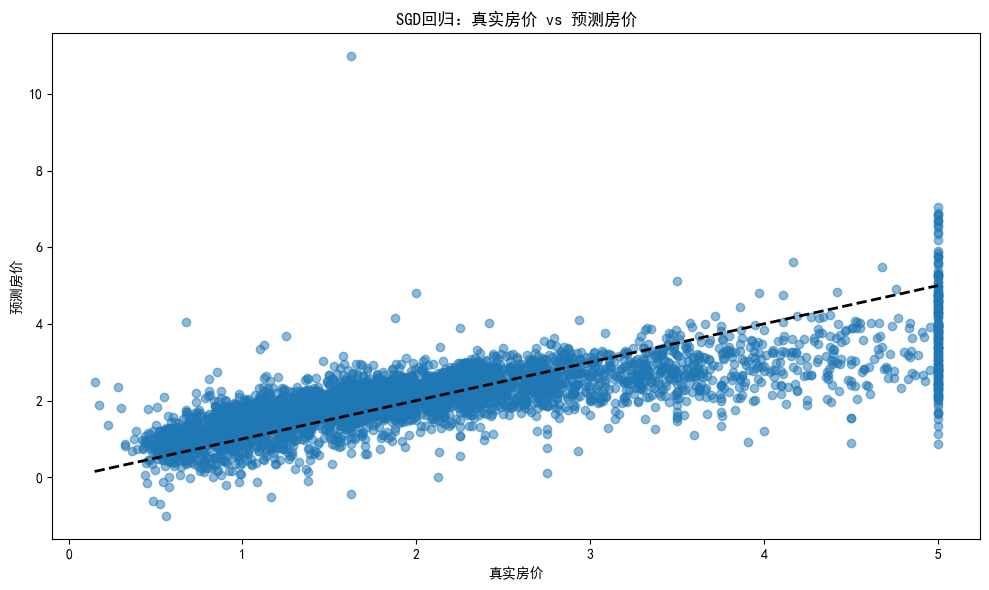

In [13]:
# SGDRegressor：随机梯度下降求解线性回归（适合大规模数据，逐样本更新参数）

import numpy as np  # 数值计算
import pandas as pd  # 数据处理
import matplotlib.pyplot as plt  # 绘图
from sklearn.datasets import fetch_california_housing  # 加载数据集
from sklearn.model_selection import train_test_split  # 数据集划分
from sklearn.linear_model import SGDRegressor  # 在线/小批量梯度下降回归器
from sklearn.metrics import mean_squared_error, r2_score  # 评估指标
from sklearn.preprocessing import StandardScaler  # SGD 对特征尺度敏感，必须标准化
import joblib  # 模型序列化工具

housing = fetch_california_housing(data_home='./data')  # 加载数据
X = housing.data  # 特征矩阵；ndarray，(20640, 8)
y = housing.target  # 目标值；ndarray，(20640,)

missing_values = np.isnan(X).sum()  # 检查特征缺失
print("特征中的缺失值:")  # 打印标题
print(missing_values)  # 各列缺失数

missing_target = np.isnan(y).sum()  # 检查目标缺失
print(f"目标变量中的缺失值: {missing_target}")  # 打印缺失数

if missing_values.sum() == 0 and missing_target == 0:  # 判断数据完整性
    print("\n数据集完整，没有缺失值或无穷大值。")  # 完整提示
else:  # 否则
    print("\n数据集存在缺失值或无穷大值，需要进行数据清洗。")  # 清洗提示

print("特征名称:", housing.feature_names)  # 8 个特征名
print("数据集形状:", X.shape)  # (20640, 8)
print("目标变量形状:", y.shape)  # (20640,)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 划分数据集
print(y_train[:10])  # 打印前 10 个训练标签

scaler = StandardScaler()  # 初始化标准化器
X_train_scaled = scaler.fit_transform(X_train)  # 在训练集上 fit 并 transform
X_test_scaled = scaler.transform(X_test)  # 用训练统计量变换测试集

# max_iter：最大 epoch 数；tol：相邻 epoch 损失变化 < tol 时提前停止；eta0：初始学习率
sgd_model = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42, eta0=0.01)  # 初始化 SGD 回归器

sgd_model.fit(X_train_scaled, y_train)  # 多 epoch 遍历训练集，每次随机取一个样本更新参数

y_pred = sgd_model.predict(X_test_scaled)  # 预测测试集；返回 ndarray

mse = mean_squared_error(y_test, y_pred)  # 均方误差；float
print(f"均方误差 (MSE): {mse:.4f}")  # 打印 MSE

print("\n模型回归系数:")  # 打印标题
for name, coef in zip(housing.feature_names, sgd_model.coef_):  # 遍历特征名与系数对
    print(f"{name}: {coef:.4f}")  # 打印每个特征的系数
print(f"截距: {sgd_model.intercept_[0]:.4f}")  # SGDRegressor.intercept_ 为一维数组；取第0个元素

joblib.dump(sgd_model, 'sgd_regression_model.pkl')  # 保存 SGD 模型
joblib.dump(scaler, 'scaler.pkl')  # 保存标准化器
print("\n模型和标准化器已保存")  # 打印保存确认

plt.figure(figsize=(10, 6))  # 创建图窗
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False  # 禁用 unicode 负号
plt.scatter(y_test, y_pred, alpha=0.5)  # 散点图
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # y=x 参考线
plt.xlabel('真实房价')  # x 轴标签
plt.ylabel('预测房价')  # y 轴标签
plt.title('SGD回归：真实房价 vs 预测房价')  # 图标题
plt.tight_layout()  # 自动调整布局
plt.show()  # 渲染图像


# 实战Lasso回归，岭回归

Lasso回归
均方误差 (MSE): 0.5483

Lasso回归系数:
MedInc: 0.8010
HouseAge: 0.1271
AveRooms: -0.1628
AveBedrms: 0.2062
Population: -0.0000
AveOccup: -0.0306
Latitude: -0.7901
Longitude: -0.7557
截距: 2.0719


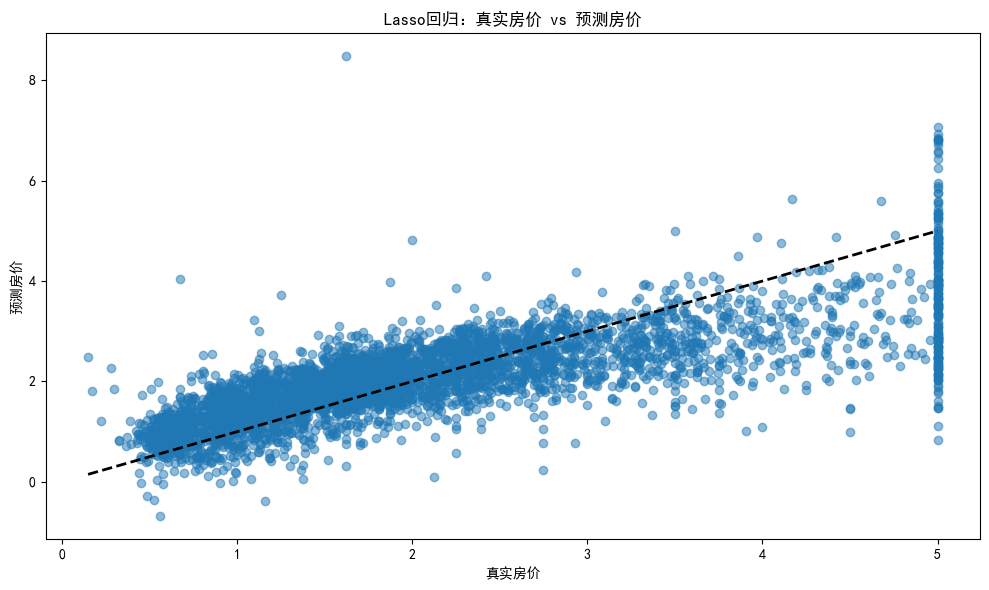


岭回归
均方误差 (MSE): 0.5559

岭回归系数:
MedInc: 0.8543
HouseAge: 0.1226
AveRooms: -0.2942
AveBedrms: 0.3390
Population: -0.0023
AveOccup: -0.0408
Latitude: -0.8962
Longitude: -0.8691
截距: 2.0719


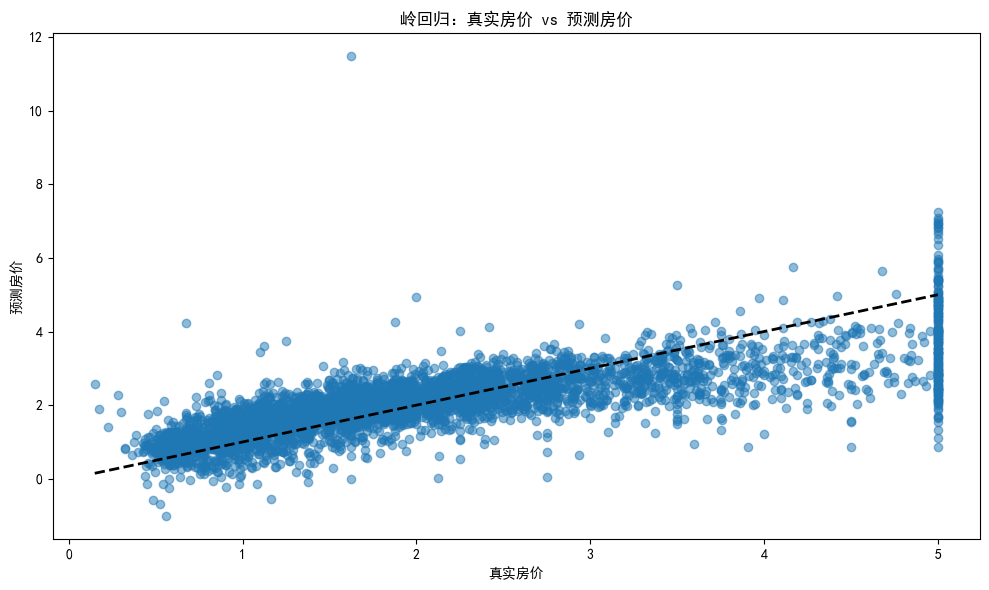

In [16]:
# Lasso（L1 正则）与 Ridge（L2 正则）回归：正则化防止过拟合
from sklearn.linear_model import Lasso, Ridge  # Lasso：系数稀疏化；Ridge：系数整体缩小
from sklearn.metrics import mean_squared_error, r2_score  # 评估指标
from sklearn.model_selection import GridSearchCV  # 超参数网格搜索
import numpy as np  # 数值计算
import matplotlib.pyplot as plt  # 绘图

print("="*50)  # 打印分隔线
print("Lasso回归")  # 打印标题
print("="*50)  # 打印分隔线

# alpha 为正则化强度；alpha 越大，系数被压缩越多；max_iter 增大确保收敛
lasso_model = Lasso(alpha=0.01, random_state=42, max_iter=10000)  # 初始化 Lasso；L1惩罚=α·Σ|w|

lasso_model.fit(X_train_scaled, y_train)  # 在标准化训练集上拟合；依赖上一 cell 的变量

lasso_pred = lasso_model.predict(X_test_scaled)  # 预测测试集；返回 ndarray

lasso_mse = mean_squared_error(y_test, lasso_pred)  # 计算 Lasso 的 MSE；float
print(f"均方误差 (MSE): {lasso_mse:.4f}")  # 打印 Lasso MSE

print("\nLasso回归系数:")  # 打印标题
for name, coef in zip(housing.feature_names, lasso_model.coef_):  # 遍历特征名与系数
    print(f"{name}: {coef:.4f}")  # L1 正则下部分系数可能精确为 0（特征自动选择）
print(f"截距: {lasso_model.intercept_:.4f}")  # 截距；标量 float

plt.figure(figsize=(10, 6))  # 创建图窗
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False  # 禁用 unicode 负号
plt.scatter(y_test, lasso_pred, alpha=0.5)  # 散点图
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # y=x 参考线
plt.xlabel('真实房价')  # x 轴标签
plt.ylabel('预测房价')  # y 轴标签
plt.title('Lasso回归：真实房价 vs 预测房价')  # 图标题
plt.tight_layout()  # 自动调整布局
plt.show()  # 渲染图像

print("\n"+"="*50)  # 打印分隔线
print("岭回归")  # 打印标题
print("="*50)  # 打印分隔线

ridge_model = Ridge(alpha=1.0, random_state=42)  # 初始化岭回归；L2惩罚=α·Σw²；系数不会变 0

ridge_model.fit(X_train_scaled, y_train)  # 拟合岭回归模型

ridge_pred = ridge_model.predict(X_test_scaled)  # 预测测试集；返回 ndarray

ridge_mse = mean_squared_error(y_test, ridge_pred)  # 计算 Ridge 的 MSE；float
print(f"均方误差 (MSE): {ridge_mse:.4f}")  # 打印 Ridge MSE

print("\n岭回归系数:")  # 打印标题
for name, coef in zip(housing.feature_names, ridge_model.coef_):  # 遍历特征名与系数
    print(f"{name}: {coef:.4f}")  # L2 正则下系数均收缩但不为 0
print(f"截距: {ridge_model.intercept_:.4f}")  # 截距；标量 float

plt.figure(figsize=(10, 6))  # 创建图窗
plt.scatter(y_test, ridge_pred, alpha=0.5)  # 散点图
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # y=x 参考线
plt.xlabel('真实房价')  # x 轴标签
plt.ylabel('预测房价')  # y 轴标签
plt.title('岭回归：真实房价 vs 预测房价')  # 图标题
plt.tight_layout()  # 自动调整布局
plt.show()  # 渲染图像


# 逻辑回归

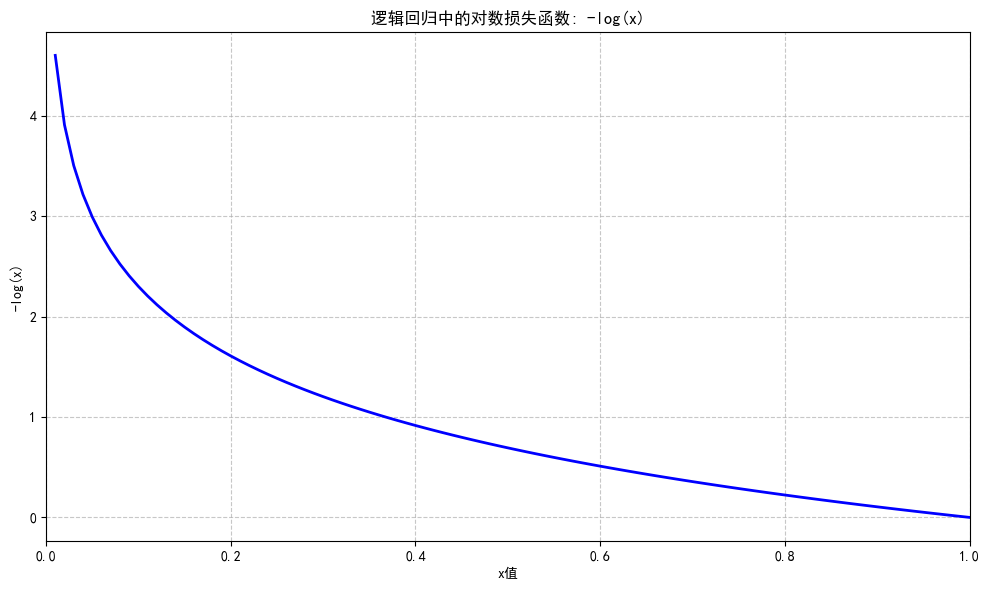

In [17]:
# 逻辑回归损失函数之一：-log(p)，当真实标签=1 时预测概率越低损失越大

import numpy as np  # 数值计算
import matplotlib.pyplot as plt  # 绘图

x = np.linspace(0.01, 1, 100)  # 生成 100 个点；从 0.01 开始避免 log(0)=−∞

y = -np.log(x)  # 计算 -log(p)；p→0 时损失→∞，p→1 时损失→0；体现「预测越错惩罚越大」

plt.figure(figsize=(10, 6))  # 创建图窗
plt.plot(x, y, 'b-', linewidth=2)  # 绘制蓝色实线曲线
plt.grid(True, linestyle='--', alpha=0.7)  # 显示虚线网格，透明度 0.7
plt.xlabel('x值')  # x 轴表示预测概率 p
plt.ylabel('-log(x)')  # y 轴表示损失值
plt.title('逻辑回归中的对数损失函数: -log(x)')  # 图标题
plt.xlim(0, 1)  # 限制 x 轴范围为 [0,1]（概率的定义域）
plt.tight_layout()  # 自动调整布局
plt.show()  # 渲染图像


C:\Users\41507\AppData\Local\Temp\ipykernel_31860\2569910477.py:8: RuntimeWarning: divide by zero encountered in log
  y = -np.log(1-x)


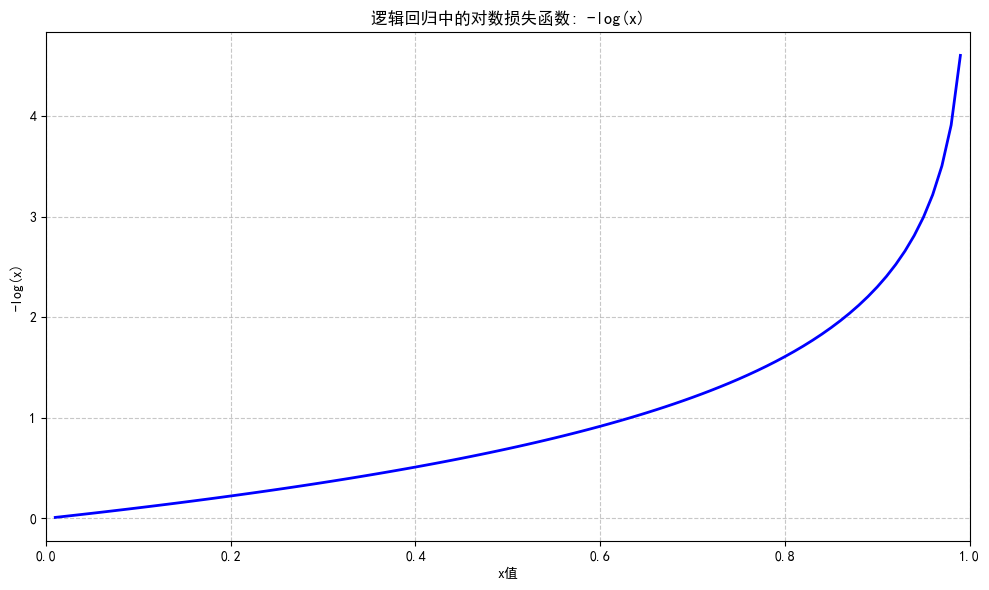

In [18]:
# 逻辑回归损失函数之二：-log(1-p)，当真实标签=0 时预测概率越高损失越大

import numpy as np  # 数值计算
import matplotlib.pyplot as plt  # 绘图

x = np.linspace(0.01, 1, 100)  # 同上，生成 100 个概率采样点

y = -np.log(1-x)  # 计算 -log(1-p)；p→1 时损失→∞，p→0 时损失→0；与上图互补

plt.figure(figsize=(10, 6))  # 创建图窗
plt.plot(x, y, 'b-', linewidth=2)  # 绘制蓝色实线曲线
plt.grid(True, linestyle='--', alpha=0.7)  # 显示虚线网格
plt.xlabel('x值')  # x 轴表示预测概率 p
plt.ylabel('-log(x)')  # y 轴表示损失值（此处实际为 -log(1-x)）
plt.title('逻辑回归中的对数损失函数: -log(1-x)')  # 图标题
plt.xlim(0, 1)  # 限制 x 轴范围
plt.tight_layout()  # 自动调整布局
plt.show()  # 渲染图像


In [26]:
# 威斯康星乳腺癌数据集：数据清洗 → 逻辑回归二分类（良性/恶性）

import pandas as pd  # 数据处理
import numpy as np  # 数值计算

df = pd.read_csv('data/breast-cancer-wisconsin.csv', header=None)  # 读取 CSV；header=None 表示无列名行

df = df.replace('?', np.nan)  # 将字符串 '?' 替换为 np.nan，使 pandas 能识别为缺失值

print("\n每列缺失值数量:")  # 打印标题
print(df.isna().sum())  # 每列缺失个数；返回 Series

print("\n数据基本信息:")  # 打印标题
print(df.info())  # 打印每列的数据类型、非空计数等信息

df_clean = df.dropna()  # 删除含任意缺失的行；返回新 DataFrame
print(f"\n删除缺失值后的数据形状: {df_clean.shape}")  # 打印清洗后的行列数

columns = ['ID', 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape',  # 列名列表（前4个）
           'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei',  # 列名列表（中间3个）
           'Bland Chromatin', 'Normal Nucleoli', 'Mitoses', 'Class']  # 列名列表（最后3个）
df_clean.columns = columns  # 赋予有医学意义的列名

print("\n数据的基本统计信息:")  # 打印标题
print(df_clean.describe())  # 打印各数值列的 count/mean/std/min/25%/50%/75%/max

print("\n类别分布:")  # 打印标题
print(df_clean['Class'].value_counts())  # 打印各类别样本数；2=良性，4=恶性

X = df_clean.drop(['ID', 'Class'], axis=1)  # 删除 ID 列（无意义）和标签列；返回 9 列特征 DataFrame
y = df_clean['Class']  # 标签列；Series，值为 2 或 4

from sklearn.model_selection import train_test_split  # 导入划分工具
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 80%训练，20%测试

print(f"\n训练集大小: {X_train.shape}")  # 打印训练集形状
print(f"测试集大小: {X_test.shape}")  # 打印测试集形状

from sklearn.linear_model import LogisticRegression  # 逻辑回归分类器
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc  # 评估工具

# C 越小正则化越强；penalty='l2' 即 L2 正则；liblinear 适合小数据集
model = LogisticRegression(C=0.1, penalty='l2', solver='liblinear', max_iter=1000)  # 初始化逻辑回归

model.fit(X_train, y_train)  # 用梯度下降（或坐标下降）拟合逻辑回归参数

y_pred = model.predict(X_test)  # 硬分类预测；返回 ndarray，值为 2 或 4
y_pred_prob = model.predict_proba(X_test)  # 软分类预测；返回 ndarray，形状 (n_samples, n_classes)

print("\n模型评估:")  # 打印标题
print(f"准确率: {accuracy_score(y_test, y_pred):.4f}")  # 打印准确率

print(y_pred[0:5])  # 打印前 5 条预测标签（2 或 4）
y_pred_prob  # 显示概率矩阵；Jupyter 最后一行自动渲染



每列缺失值数量:
0      0
1      0
2      0
3      0
4      0
5      0
6     16
7      0
8      0
9      0
10     0
dtype: int64

数据基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       699 non-null    int64 
 1   1       699 non-null    int64 
 2   2       699 non-null    int64 
 3   3       699 non-null    int64 
 4   4       699 non-null    int64 
 5   5       699 non-null    int64 
 6   6       683 non-null    object
 7   7       699 non-null    int64 
 8   8       699 non-null    int64 
 9   9       699 non-null    int64 
 10  10      699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB
None

删除缺失值后的数据形状: (683, 11)

数据的基本统计信息:
                 ID  Clump Thickness  Uniformity of Cell Size  \
count  6.830000e+02       683.000000               683.000000   
mean   1.076720e+06         4.442167                 3.150805   
std    6

array([[4.50691460e-02, 9.54930854e-01],
       [6.56516750e-02, 9.34348325e-01],
       [9.25797276e-01, 7.42027239e-02],
       [8.91911972e-01, 1.08088028e-01],
       [8.81855004e-01, 1.18144996e-01],
       [9.23209255e-01, 7.67907452e-02],
       [8.11848390e-01, 1.88151610e-01],
       [8.31395499e-01, 1.68604501e-01],
       [1.84935198e-01, 8.15064802e-01],
       [9.15962267e-01, 8.40377327e-02],
       [8.97656556e-01, 1.02343444e-01],
       [9.10942305e-01, 8.90576952e-02],
       [9.24207590e-01, 7.57924104e-02],
       [9.54738816e-01, 4.52611841e-02],
       [6.56395333e-01, 3.43604667e-01],
       [1.82918827e-02, 9.81708117e-01],
       [9.44743870e-01, 5.52561296e-02],
       [1.81208200e-03, 9.98187918e-01],
       [8.04007941e-01, 1.95992059e-01],
       [7.06531834e-02, 9.29346817e-01],
       [7.47816942e-03, 9.92521831e-01],
       [8.68134907e-01, 1.31865093e-01],
       [3.30555303e-03, 9.96694447e-01],
       [9.25797276e-01, 7.42027239e-02],
       [8.029234